In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState


In [2]:
from langchain.chat_models import init_chat_model

In [3]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,  model_provider="google_vertexai")

In [4]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])
    return state

In [5]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm", call_model)
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)
graph = graph_builder.compile()

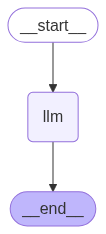

In [6]:
from utils import draw_graph
draw_graph(graph)


In [7]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [
    SystemMessage("You are an helpful assistant"),
    HumanMessage("I would like to know about democracy")

]
result = graph.invoke({"messages": messages})

In [8]:
result['messages']


[SystemMessage(content='You are an helpful assistant', additional_kwargs={}, response_metadata={}, id='3e607d90-1f6e-4b77-99d9-ac800fe5d31d'),
 HumanMessage(content='I would like to know about democracy', additional_kwargs={}, response_metadata={}, id='7ee1d4cf-7511-412c-b555-bb7c50c3e611'),
 AIMessage(content='Democracy is a fascinating and complex system of government! Since you\'ve asked broadly, I\'ll give you a comprehensive overview.\n\nAt its core, **democracy** is a system of government where the supreme power is vested in the **people** and exercised by them directly or indirectly through a system of representation, usually involving periodically held free and fair elections.\n\nLet\'s break down its key aspects:\n\n---\n\n### I. Core Principles of Democracy\n\n1.  **Popular Sovereignty:** The ultimate power and authority reside in the people. The government\'s legitimacy comes from the consent of the governed.\n2.  **Political Equality:** Every citizen has an equal right to p

In [9]:
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an helpful assistant
================================ Human Message =================================

I would like to know about democracy
================================== Ai Message ==================================

Democracy is a fascinating and complex system of government! Since you've asked broadly, I'll give you a comprehensive overview.

At its core, **democracy** is a system of government where the supreme power is vested in the **people** and exercised by them directly or indirectly through a system of representation, usually involving periodically held free and fair elections.

Let's break down its key aspects:

---

### I. Core Principles of Democracy

1.  **Popular Sovereignty:** The ultimate power and authority reside in the people. The government's legitimacy comes from the consent of the governed.
2.  **Political Equality:** Every citizen has an equal right to participate in th

In [10]:
from IPython.display import Markdown
Markdown(result['messages'][-1].content)

Democracy is a fascinating and complex system of government! Since you've asked broadly, I'll give you a comprehensive overview.

At its core, **democracy** is a system of government where the supreme power is vested in the **people** and exercised by them directly or indirectly through a system of representation, usually involving periodically held free and fair elections.

Let's break down its key aspects:

---

### I. Core Principles of Democracy

1.  **Popular Sovereignty:** The ultimate power and authority reside in the people. The government's legitimacy comes from the consent of the governed.
2.  **Political Equality:** Every citizen has an equal right to participate in the political process, typically meaning "one person, one vote."
3.  **Rule of Law:** All citizens, including those in power, are subject to and accountable under the law. Laws are applied equally and consistently.
4.  **Protection of Human Rights and Civil Liberties:** Democracies are committed to protecting fundamental rights such as freedom of speech, assembly, religion, press, and the right to a fair trial.
5.  **Free and Fair Elections:** Citizens have the right to choose their representatives through regular, competitive, and transparent elections, free from intimidation or manipulation. This includes a secret ballot.
6.  **Accountability and Transparency:** Government officials are accountable to the people and their actions should be open to public scrutiny.
7.  **Checks and Balances:** Power is divided among different branches of government (e.g., executive, legislative, judicial) to prevent any one branch from becoming too powerful.

---

### II. Types of Democracy

While the core principles remain, democracy can manifest in different forms:

1.  **Direct Democracy:**
    *   **Definition:** Citizens directly participate in decision-making and law-making, without elected representatives.
    *   **Example:** Ancient Athens. Today, some elements exist in local referendums or initiatives (e.g., in Switzerland, some U.S. states).
    *   **Pros:** High citizen engagement, direct expression of popular will.
    *   **Cons:** Impractical for large populations, can be slow, potential for "tyranny of the majority."

2.  **Representative Democracy (Republic):**
    *   **Definition:** Citizens elect representatives to make decisions on their behalf. This is the most common form of democracy today.
    *   **Examples:** United States, Canada, United Kingdom, India, Germany, etc.
    *   **Pros:** Scalable for large populations, allows for specialized knowledge, elected officials can deliberate more thoroughly.
    *   **Cons:** Potential for representatives to become disconnected from their constituents, risk of special interest influence.
    *   **Sub-types within Representative Democracy:**
        *   **Parliamentary Democracy:** The executive branch (Prime Minister/Chancellor) is drawn from and accountable to the legislative branch (Parliament). (e.g., UK, Germany, Canada).
        *   **Presidential Democracy:** The executive (President) is elected independently of the legislature and serves a fixed term. (e.g., USA, Brazil).
        *   **Semi-Presidential Democracy:** A mix, with both a directly elected president and a prime minister accountable to the legislature. (e.g., France, Russia).

---

### III. Historical Roots

*   **Ancient Greece (Athens, c. 500 BCE):** Often cited as the birthplace of direct democracy, though only a minority of the population (free adult male citizens) could participate.
*   **Roman Republic (c. 509 BCE):** Introduced concepts of republicanism, elected officials, and a system of laws, influencing later ideas of representative government.
*   **Magna Carta (1215 CE):** Limited the power of the English monarch, laying groundwork for constitutionalism.
*   **Enlightenment Thinkers (17th-18th Centuries):** Philosophers like John Locke, Jean-Jacques Rousseau, and Montesquieu developed theories of natural rights, social contract, and separation of powers that profoundly influenced modern democratic thought.
*   **American Revolution (1776) & French Revolution (1789):** Practical implementations of Enlightenment ideals, leading to the establishment of democratic republics.

---

### IV. Benefits of Democracy

*   **Protection of Rights:** Generally safeguards individual liberties and human rights more effectively than authoritarian regimes.
*   **Peaceful Transitions of Power:** Provides a legitimate and orderly mechanism for leadership change through elections, reducing the likelihood of violent coups.
*   **Citizen Participation:** Encourages people to engage in public life and have a say in their governance.
*   **Adaptability and Self-Correction:** Democracies can adapt to changing circumstances and correct past mistakes through public debate, elections, and policy changes.
*   **Stability:** Though sometimes appearing chaotic, democracies tend to be more stable in the long run because they have mechanisms for addressing grievances.
*   **Economic Prosperity:** While not always causal, many prosperous nations are democracies, as they often foster innovation, property rights, and a stable environment for business.

---

### V. Challenges and Criticisms of Democracy

*   **Tyranny of the Majority:** The concern that the majority can impose its will on minority groups, suppressing their rights or interests.
*   **Inefficiency and Slow Decision-Making:** The need for deliberation, consensus-building, and checks and balances can make democratic processes slow.
*   **Voter Apathy/Disillusionment:** Citizens may become disengaged if they feel their vote doesn't matter or that politicians are unresponsive.
*   **Polarization:** Political systems can become highly divided, making compromise difficult and leading to gridlock.
*   **Influence of Money/Special Interests:** Wealthy individuals or powerful lobbying groups can disproportionately influence policy.
*   **Misinformation and Disinformation:** The spread of false information, especially through digital media, can undermine informed public debate and elections.
*   **Demagoguery:** The risk of populist leaders appealing to emotions and prejudices rather than rational arguments.

---

Democracy is an ongoing experiment, continually evolving and facing new challenges. It's not a perfect system, but for many, it remains the most desirable form of governance because it upholds the dignity and autonomy of the individual.

What aspects of democracy are you most interested in exploring further? For example:
*   Its historical development?
*   Specific types or examples?
*   Its challenges in the modern world?
*   How it compares to other systems of government?

In [11]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [SystemMessage("you are and helpful assistant"),
            HumanMessage("what is langgraph")]

In [12]:
#synchronous
for chunk in graph.stream({"messages": messages},stream_mode="updates"):
    print(chunk)


{'llm': {'messages': AIMessage(content='**LangGraph is an extension of LangChain designed for building more robust, stateful, and multi-turn LLM applications using a graph-based approach.**\n\nThink of it as a way to define complex, non-linear workflows for your LLM agents, rather than just sequential chains.\n\nHere\'s a breakdown:\n\n---\n\n### The Problem It Solves (Why LangGraph Exists)\n\nTraditional LangChain `Chains` are great for sequential operations (e.g., "take user input, pass to LLM, parse output"). LangChain `Agents` are more dynamic, allowing the LLM to choose tools. However, both can sometimes struggle with:\n\n1.  **Statefulness over multiple turns:** Maintaining context, memory, and previous actions in a robust way for complex, multi-step interactions.\n2.  **Complex Logic & Control Flow:** Implementing loops, conditional branching, human-in-the-loop steps, or self-correction mechanisms in a deterministic and manageable way.\n3.  **Reliability and Debugging:** When an

In [13]:
#async
async for chunk in graph.astream({"messages": messages}, stream_mode="updates"):
    print(chunk)

{'llm': {'messages': AIMessage(content='**LangGraph** is an extension of the LangChain framework specifically designed for building **stateful, multi-actor applications with LLMs** using a graph-based approach.\n\nIn simpler terms, while LangChain provides powerful tools for building linear sequences of LLM calls (chains) and single-turn agentic behaviors, LangGraph takes it a significant step further by allowing you to define complex, **cyclical workflows** that manage state and enable sophisticated agentic reasoning.\n\n### Why does LangGraph exist? (The Problem it Solves)\n\nTraditional LangChain chains are often linear: do step A, then step B, then step C. While powerful, many real-world LLM applications, especially intelligent agents, require:\n\n1.  **Iteration and Self-Correction:** An agent might try to answer a question, realize it needs more information, go fetch it, and then try again. This requires looping back.\n2.  **Complex Conditional Logic:** "If the LLM\'s output is X

In [14]:

# synchronous
llm.invoke(messages)

AIMessage(content='To understand LangGraph, it\'s helpful to first briefly understand its parent framework, **LangChain**.\n\n---\n\n### 1. What is LangChain?\n\n**LangChain** is a powerful open-source framework designed to help developers build applications powered by large language models (LLMs). It provides a structured way to:\n\n*   **Connect LLMs to external data:** Like documents, databases, APIs, etc. (e.g., for Retrieval Augmented Generation - RAG).\n*   **Allow LLMs to interact with their environment:** Through "tools" (e.g., search engines, calculators, custom functions).\n*   **Compose multiple LLM calls:** Into complex "chains" or "agents" to achieve more sophisticated tasks.\n\nThink of LangChain as a toolbox that provides abstractions for common LLM application patterns:\n*   **Models:** Interfaces for different LLMs (OpenAI, Anthropic, Hugging Face).\n*   **Prompts:** Templates for crafting effective prompts.\n*   **Chains:** Sequences of calls to LLMs or other utilitie

In [15]:
# async
async for chunk in llm.astream(messages):
    print(chunk)

content="**LangGraph** is an extension of the LangChain framework designed specifically for building **stateful, multi-actor applications with LLMs**.\n\nThink of it as adding a robust, graph-based control layer on top of LangChain's" additional_kwargs={} response_metadata={'safety_ratings': [], 'usage_metadata': {}} id='run--033165d0-6f15-4f1f-8dd6-2fcc0b683246'
content=" existing components (LLMs, tools, chains, etc.).\n\nHere's a breakdown of what that means:\n\n### The Problem LangGraph Solves\n\nWhile LangChain agents are powerful for many tasks, they often struggle with:\n\n1.  **State Management:** Maintaining and evolving a shared state across multiple steps" additional_kwargs={} response_metadata={'safety_ratings': [], 'usage_metadata': {}} id='run--033165d0-6f15-4f1f-8dd6-2fcc0b683246'
content=' or turns in a complex workflow.\n2.  **Complex Control Flow:** Handling conditional logic, loops, human intervention, and re-planning when an LLM\'s initial attempt fails.\n3.  **Mult

In [16]:
async for chunk in llm.astream(messages):
    if chunk.content:
        print(chunk.content)

**LangGraph** is a library that extends the capabilities of LangChain by
 providing a way to build **stateful, multi-actor applications with cyclical computation** using a graph-based approach.

In simpler terms, while standard LangChain is excellent for building linear chains of operations (e.g., prompt -> LLM -> parser), LangGraph allows you to design much more complex, dynamic
, and robust applications that can:

1.  **Maintain and update state:** Information can be passed between different steps (nodes) and evolved throughout the application's execution.
2.  **Perform conditional logic:** The flow of execution can branch based on decisions made by an LLM or other components.
3.  **Support
 cycles/loops:** An application can return to a previous step, which is crucial for things like agentic behavior (e.g., an AI agent trying a tool, then reflecting on the result, and trying another tool if needed).
4.  **Orchestrate multiple "actors" or agents:** Different LL
Ms, tools, or human in

In [17]:
from typing import TypedDict
class MyState(TypedDict):
    message: str

In [18]:
from time import sleep
def node_1(state: MyState) -> MyState:
    state['message'] = "Im in node 1"
    sleep(2)
    return state

def node_2(state: MyState) -> MyState:
    state['message'] = "Im in node 2"
    sleep(2)
    return state

def node_3(state: MyState) -> MyState:
    state['message'] = "Im in node 3"
    sleep(2)
    return state

def node_4(state: MyState) -> MyState:
    state['message'] = "Im in node 4"
    sleep(2)
    return state

def node_5(state: MyState) -> MyState:
    state['message'] = "Im in node 5"
    sleep(2)
    return state

In [19]:
my_graph_builder = StateGraph(MyState)
my_graph_builder.add_node("node1", node_1)
my_graph_builder.add_node("node2", node_2)
my_graph_builder.add_node("node3", node_3)
my_graph_builder.add_node("node4", node_4)
my_graph_builder.add_node("node5", node_5)
my_graph_builder.set_entry_point("node1")
my_graph_builder.set_finish_point("node5")
my_graph_builder.add_edge("node1", "node2")
my_graph_builder.add_edge("node2", "node3")
my_graph_builder.add_edge("node3", "node4")
my_graph_builder.add_edge("node4", "node5")
my_graph = my_graph_builder.compile()

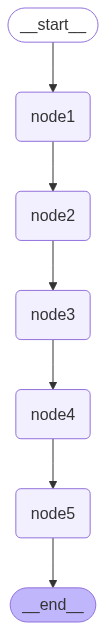

In [20]:
from utils import draw_graph
draw_graph(my_graph)

In [21]:
for chunk in my_graph.stream({"message": ""}, stream_mode="updates"):
    print(chunk)

{'node1': {'message': 'Im in node 1'}}
{'node2': {'message': 'Im in node 2'}}
{'node3': {'message': 'Im in node 3'}}
{'node4': {'message': 'Im in node 4'}}
{'node5': {'message': 'Im in node 5'}}


In [22]:
for chunk in my_graph.stream({"message": ""}, stream_mode="debug"):
    print(chunk)

{'type': 'task', 'timestamp': '2025-06-13T06:06:57.691954+00:00', 'step': 1, 'payload': {'id': '9559f299-747a-c3d9-9fa7-4fbbdefc134f', 'name': 'node1', 'input': {'message': ''}, 'triggers': ('branch:to:node1',)}}
{'type': 'task_result', 'timestamp': '2025-06-13T06:06:59.693915+00:00', 'step': 1, 'payload': {'id': '9559f299-747a-c3d9-9fa7-4fbbdefc134f', 'name': 'node1', 'error': None, 'result': [('message', 'Im in node 1')], 'interrupts': []}}
{'type': 'task', 'timestamp': '2025-06-13T06:06:59.693915+00:00', 'step': 2, 'payload': {'id': 'e0315b23-6b06-8a6b-3c3d-d717be6ad791', 'name': 'node2', 'input': {'message': 'Im in node 1'}, 'triggers': ('branch:to:node2',)}}
{'type': 'task_result', 'timestamp': '2025-06-13T06:07:01.696406+00:00', 'step': 2, 'payload': {'id': 'e0315b23-6b06-8a6b-3c3d-d717be6ad791', 'name': 'node2', 'error': None, 'result': [('message', 'Im in node 2')], 'interrupts': []}}
{'type': 'task', 'timestamp': '2025-06-13T06:07:01.696406+00:00', 'step': 3, 'payload': {'id':